In [ ]:
from google.colab import files
uploaded = files.upload()

Saving NewSampleFRAUDLENS360.csv to NewSampleFRAUDLENS360.csv


In [ ]:
import pandas as pd
df = pd.read_csv('NewSampleFRAUDLENS360.csv')
print(df.shape)
print(df['isFraud'].value_counts())

(249999, 11)
isFraud
0    249836
1       163
Name: count, dtype: int64


In [ ]:
!pip install shap -q

In [ ]:
print(df.columns.tolist())


['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['type_enc'] = le.fit_transform(df['type'])

df['orig_balance_delta'] = df['newbalanceOrig'] - df['oldbalanceOrg']
df['dest_balance_delta'] = df['newbalanceDest'] - df['oldbalanceDest']
df['amount_to_orig_balance'] = df['amount'] / (df['oldbalanceOrg'] + 1)
df['orig_balance_zeroed'] = (df['newbalanceOrig'] == 0).astype(int)

FEATURES = [
    'type_enc', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'orig_balance_delta',
    'dest_balance_delta', 'amount_to_orig_balance', 'orig_balance_zeroed'
]

X = df[FEATURES]
y = df['isFraud']

print('Features ready ✓')
print(f'X shape: {X.shape}')

Features ready ✓
X shape: (249999, 10)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape[0]:,} rows')
print(f'Test:  {X_test.shape[0]:,} rows')
print(f'Fraud in test: {y_test.sum()}')

Train: 199,999 rows
Test:  50,000 rows
Fraud in test: 33


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print('Model trained ✓')

Model trained ✓


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
print(f'AUC-ROC Score: {auc:.4f}\n')
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))


AUC-ROC Score: 0.9540

              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     49967
       Fraud       1.00      0.91      0.95        33

    accuracy                           1.00     50000
   macro avg       1.00      0.95      0.98     50000
weighted avg       1.00      1.00      1.00     50000



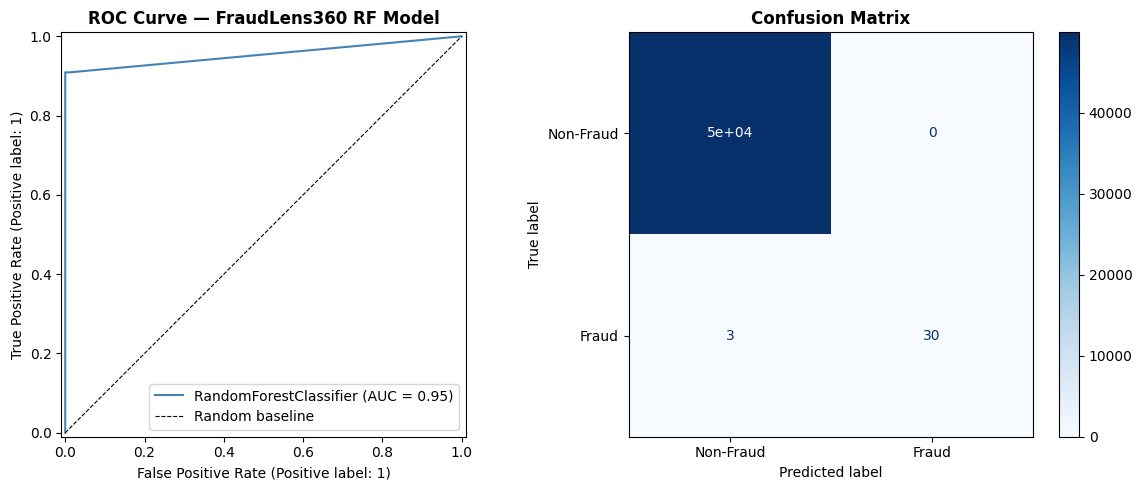

Saved ✓


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=axes[0], color='steelblue')
axes[0].set_title('ROC Curve — FraudLens360 RF Model', fontweight='bold')
axes[0].plot([0,1],[0,1],'k--', linewidth=0.8, label='Random baseline')
axes[0].legend()

ConfusionMatrixDisplay.from_estimator(
    rf, X_test, y_test,
    display_labels=['Non-Fraud', 'Fraud'],
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title('Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('fraud_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ✓')

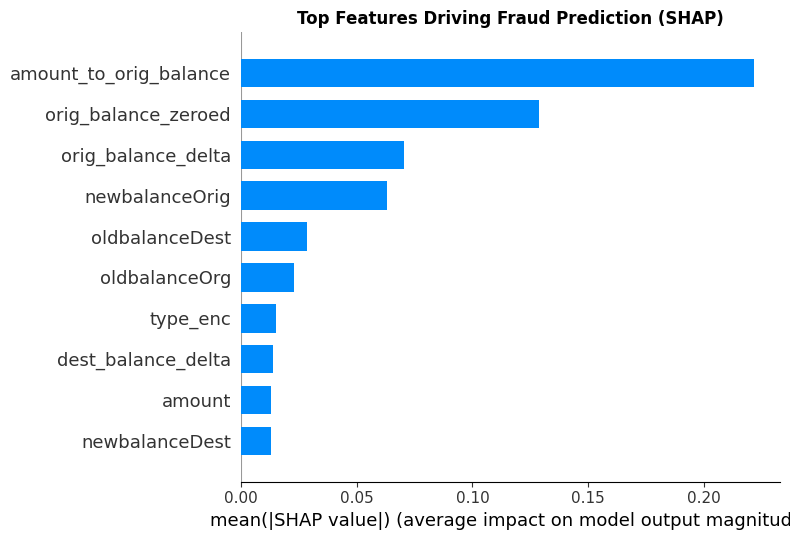

Saved ✓


In [ ]:
import shap

X_sample = X_test.sample(n=500, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample,
    plot_type='bar',
    show=False
)
plt.title('Top Features Driving Fraud Prediction (SHAP)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ✓')

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print('=' * 60)
print(' RESUME BULLET — ')
print('=' * 60)
print(f"""
Extended rule-based fraud identification pipeline with a
Random Forest classifier (scikit-learn); achieved AUC of
{auc:.2f} with {precision*100:.0f}% precision at {recall*100:.0f}% recall —
validating SQL heuristic rules against an ML baseline on
250K transactions. Applied SHAP explainability to identify
top fraud drivers: account drain ratio, balance zeroing,
and balance delta patterns.
""")

 RESUME BULLET — 

Extended rule-based fraud identification pipeline with a 
Random Forest classifier (scikit-learn); achieved AUC of 
0.95 with 100% precision at 91% recall — 
validating SQL heuristic rules against an ML baseline on 
250K transactions. Applied SHAP explainability to identify 
top fraud drivers: account drain ratio, balance zeroing, 
and balance delta patterns.

